# Notebook 3 — Constraints, Chain Rules, and the Bound-Active Diagnostic

## What this notebook teaches

Two new ingredients build on Notebooks 1–2:

1. **Chain rule for constraints.** When you add shape variability under a fixed-area constraint, two shape DOFs ($\alpha, \beta$) collapse to one (the aspect ratio) via $\beta = a/(4\alpha)$. The gradient with respect to the surviving variable picks up a chain-rule factor: $\partial f/\partial\alpha\big|_\mathrm{constrained} = \partial f/\partial\alpha - (\beta/\alpha)\,\partial f/\partial\beta$. This is the standard implicit-function-theorem move; the new bit is recognizing when it applies and tracking the sign.

2. **The bound-active diagnostic.** When optimization runs the design variable to a bound, you don't yet know whether (a) you bounded incorrectly and a real interior optimum sits just outside, (b) the bound is a hard physical limit and the bound itself is the answer, or (c) there's no interior optimum at all and the problem is degenerate. The diagnostic to distinguish: *widen the bound and rerun*. If the optimum stays at the new wider bound, the problem has no interior optimum. This is a one-line test that saves you from claiming a fictional optimum.

The application is multi-gap optimization with shape variability under area constraints. The diagnostic finding for this framework: the $\mu_\max$ (or $\sigma_\min$) optimum at fixed area runs to the aspect-ratio bound and keeps running as the bound widens. The "best" rectangular gap is asymptotically a slit. This is a hint of something deeper that Notebook 4 will pin down: the underlying objective is degenerate over free shapes, the rectangular family is just feeling that degeneracy parametrically.


## Setup

Same multi-gap problem as Notebook 2, but now we let shape vary under fixed area $4\alpha\beta = a_0$ for each gap. Three gaps, three centroids, three half-widths $\alpha_k$ (with $\beta_k = a_0/(4\alpha_k)$ inferred). Nine DOFs total.

Bounds matter here in a way they didn't before. The aspect ratio $\alpha/\beta = 4\alpha^2/a_0$ ranges from $\alpha_\min^2 \cdot 4/a_0$ at the lower bound to $\alpha_\max^2 \cdot 4/a_0$ at the upper. We'll start with a bound of $\alpha \in [0.025, 0.30]$ (aspect ratio range $[0.14, 20]$, so a square gap or an extreme slit), then widen and observe.

We continue using the multi-gap σ_min objective from Notebook 2.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
from scipy.optimize import minimize

L, W = 1.0, np.sqrt(2)
Mx, Ny = 10, 10
N = Mx * Ny
K_gaps = 3
a_0 = 0.018         # fixed area per gap

def build_J_1d(M, x0, half, L_dom):
    x_lo, x_hi = x0-half, x0+half
    Jm = np.zeros((M, M)); ks = np.arange(1, M+1)*np.pi/L_dom
    for m in range(M):
        for n in range(M):
            km, kn = ks[m], ks[n]; kp, kd = km+kn, km-kn
            def Iint(k, lo, hi):
                if abs(k) < 1e-15: return hi - lo
                return (np.sin(k*hi) - np.sin(k*lo)) / k
            Jm[m,n] = 0.5*(Iint(kd, x_lo, x_hi) - Iint(kp, x_lo, x_hi))
    return Jm

def K_single(x0, y0, alpha, beta):
    return (4/(L*W)) * np.kron(build_J_1d(Mx, x0, alpha, L),
                               build_J_1d(Ny, y0, beta, W))

def sigma_and_grad_4D(positions, halfwidths):
    """Returns (sigma_min, grad_array of shape (K_gaps, 4)) where the 4 components are
    (d/dx0, d/dy0, d/dalpha, d/dbeta) per gap. The free-alpha-and-beta version."""
    A = np.vstack([np.eye(N) - K_single(p[0], p[1], hw[0], hw[1])
                   for p, hw in zip(positions, halfwidths)])
    U, S, Vt = svd(A, full_matrices=False)
    sig = S[-1]
    v = Vt[-1, :]; u = U[:, -1]
    Vmat = v.reshape(Mx, Ny)
    grads = np.zeros((K_gaps, 4))
    pre = 4.0/(L*W)
    for k, ((x0, y0), (al, be)) in enumerate(zip(positions, halfwidths)):
        u_mat = u[k*N:(k+1)*N].reshape(Mx, Ny)
        Jx_k = build_J_1d(Mx, x0, al, L); Jy_k = build_J_1d(Ny, y0, be, W)
        sx_R = np.sin(np.arange(1,Mx+1)*np.pi*(x0+al)/L)
        sx_L = np.sin(np.arange(1,Mx+1)*np.pi*(x0-al)/L)
        sy_T = np.sin(np.arange(1,Ny+1)*np.pi*(y0+be)/W)
        sy_B = np.sin(np.arange(1,Ny+1)*np.pi*(y0-be)/W)
        e_R = pre * (u_mat.T @ sx_R) @ Jy_k @ (Vmat.T @ sx_R)
        e_L = pre * (u_mat.T @ sx_L) @ Jy_k @ (Vmat.T @ sx_L)
        e_T = pre * (u_mat   @ sy_T) @ Jx_k @ (Vmat   @ sy_T)
        e_B = pre * (u_mat   @ sy_B) @ Jx_k @ (Vmat   @ sy_B)
        grads[k, 0] = -(e_R - e_L)            # d/dx0
        grads[k, 1] = -(e_T - e_B)            # d/dy0
        grads[k, 2] = -(e_R + e_L)            # d/dalpha (alpha widens both edges)
        grads[k, 3] = -(e_T + e_B)            # d/dbeta
    return sig, grads


## The pattern: chain rule for the area constraint

We want $\sigma_\min$ as a function of $z = (x_0^{(k)}, y_0^{(k)}, \alpha^{(k)})_k$ — three DOFs per gap, nine total — with $\beta^{(k)} = a_0 / (4\alpha^{(k)})$ inferred.

Differentiating $\beta = a_0/(4\alpha)$ gives $d\beta/d\alpha = -a_0/(4\alpha^2) = -\beta/\alpha$. So:

$$\frac{\partial \sigma_\min}{\partial \alpha^{(k)}}\bigg|_\mathrm{constrained} = \frac{\partial \sigma_\min}{\partial \alpha^{(k)}} + \frac{\partial \sigma_\min}{\partial \beta^{(k)}} \cdot \left(-\frac{\beta^{(k)}}{\alpha^{(k)}}\right) = \frac{\partial \sigma_\min}{\partial \alpha^{(k)}} - \frac{\beta^{(k)}}{\alpha^{(k)}}\frac{\partial \sigma_\min}{\partial \beta^{(k)}}.$$

That's the whole "chain rule for area constraint." One line; sign matters.

The unconstrained gradients $\partial\sigma_\min/\partial\alpha, \partial\sigma_\min/\partial\beta$ come from the bilinear edge integrals of Notebook 2 — same machinery, just summing over $\partial G^R + \partial G^L$ (since widening $\alpha$ moves both edges *outward*, so both pick up integrand contributions, with the same sign).


In [2]:
def neg_sigma_constrained(z):
    """z = (x0_1, y0_1, alpha_1, x0_2, y0_2, alpha_2, x0_3, y0_3, alpha_3).
    Returns (-sigma, -grad_chain_rule)."""
    positions  = [(z[3*k],   z[3*k+1]) for k in range(K_gaps)]
    halfwidths = [(z[3*k+2], a_0/(4*z[3*k+2])) for k in range(K_gaps)]
    sig, g4 = sigma_and_grad_4D(positions, halfwidths)
    g3 = np.zeros(3*K_gaps)
    for k in range(K_gaps):
        al = z[3*k+2]; be = a_0/(4*al)
        g3[3*k]   = g4[k, 0]                          # d/dx0
        g3[3*k+1] = g4[k, 1]                          # d/dy0
        g3[3*k+2] = g4[k, 2] - (be/al) * g4[k, 3]     # chain rule for alpha
    return -sig, -g3

# Quick sanity check on one configuration
z_test = np.array([0.25, 0.25, 0.075,  0.50, 1.00, 0.075,  0.75, 0.50, 0.075])
neg_sig, g = neg_sigma_constrained(z_test)
print(f"Test config: sigma_min = {-neg_sig:.6f}")
print(f"Constrained gradient (9 DOFs):\n  {np.array_str(g, precision=4)}")


Test config: sigma_min = 1.439524
Constrained gradient (9 DOFs):
  [ 1.0047e-01 -1.9275e-01 -7.1557e-01 -1.7068e-05 -2.2268e-04 -2.8885e-04
 -1.7813e-04 -1.5850e-03 -4.1322e-03]


## Verification — chain rule via FD on the constrained variables

The right diagnostic now is FD on the *constrained* variables: perturb $\alpha$, compute $\beta = a_0/(4\alpha)$, evaluate $\sigma_\min$ at the new point, take the difference. This automatically incorporates the chain rule. Compare to the analytical chain-rule gradient. Agreement at $10^{-7}$ confirms the chain rule is correctly applied.


In [3]:
def fd_grad_constrained(z, h=1e-6):
    g = np.zeros_like(z)
    for i in range(len(z)):
        zp = z.copy(); zm = z.copy(); zp[i] += h; zm[i] -= h
        g[i] = (-neg_sigma_constrained(zp)[0] - (-neg_sigma_constrained(zm)[0])) / (2*h)
    return g

g_anal = -neg_sigma_constrained(z_test)[1]   # restore sign
g_fd   = fd_grad_constrained(z_test)
rel = np.linalg.norm(g_anal - g_fd) / np.linalg.norm(g_fd)
print(f"Constrained gradient match: rel err = {rel:.2e}")
print(f"  analytical: {np.array_str(g_anal, precision=4)}")
print(f"  FD:         {np.array_str(g_fd,   precision=4)}")


Constrained gradient match: rel err = 1.65e-09
  analytical: [-1.0047e-01  1.9275e-01  7.1557e-01  1.7068e-05  2.2268e-04  2.8885e-04
  1.7813e-04  1.5850e-03  4.1322e-03]
  FD:         [-1.0047e-01  1.9275e-01  7.1557e-01  1.7068e-05  2.2268e-04  2.8885e-04
  1.7813e-04  1.5850e-03  4.1322e-03]


## Optimization with bounds — and the bound-active observation

Initial bound: $\alpha \in [0.025, 0.30]$. The lower bound corresponds to a tall thin slit of aspect $1/14$; the upper bound corresponds to a wide flat slit of aspect $\sim 14$. Square gap is at $\alpha = \sqrt{a_0/4} \approx 0.067$ — well in the interior.


In [4]:
def make_bounds(alpha_min, alpha_max):
    bnds = []
    beta_max = a_0/(4*alpha_min)
    for k in range(K_gaps):
        bnds.append((alpha_max + 0.005, L - alpha_max - 0.005))    # x0
        bnds.append((beta_max  + 0.005, W - beta_max  - 0.005))    # y0
        bnds.append((alpha_min,         alpha_max))                 # alpha
    return bnds

def best_with_bounds(alpha_min, alpha_max, n_starts=30, seed=0):
    bnds = make_bounds(alpha_min, alpha_max)
    rng = np.random.default_rng(seed)
    best = (np.inf, None)
    for _ in range(n_starts):
        z0 = np.array([rng.uniform(*b) for b in bnds])
        res = minimize(neg_sigma_constrained, z0, jac=True, method="L-BFGS-B", bounds=bnds,
                       options={"gtol": 1e-9, "ftol": 1e-12})
        if res.fun < best[0]:
            best = (res.fun, res.x.copy())
    return -best[0], best[1]

sigma_v1, z_v1 = best_with_bounds(0.025, 0.30)
print(f"Bound alpha in [0.025, 0.30]:")
print(f"  best sigma_min = {sigma_v1:.4f}")
for k in range(K_gaps):
    al = z_v1[3*k+2]; be = a_0/(4*al)
    print(f"  gap {k+1}: pos=({z_v1[3*k]:.3f}, {z_v1[3*k+1]:.3f}), "
          f"shape={2*al:.3f}x{2*be:.3f}, aspect={al/be:.2f}")


Bound alpha in [0.025, 0.30]:
  best sigma_min = 1.6199
  gap 1: pos=(0.499, 0.566), shape=0.600x0.030, aspect=20.00
  gap 2: pos=(0.466, 0.991), shape=0.600x0.030, aspect=20.00
  gap 3: pos=(0.670, 0.283), shape=0.600x0.030, aspect=20.00


**Observation.** Multiple gaps' $\alpha$ values sit at the upper bound $0.30$, with $\beta$ correspondingly at $0.015$ — aspect ratio 20. That's a slit, not a rectangle.

This is where you have to decide: is the slit the answer, or is the bound hiding a degenerate problem? The diagnostic is to widen the bound and re-run.

## The diagnostic: widen the bound


In [5]:
alpha_maxes = [0.15, 0.20, 0.30, 0.40]  # capped at feasible alpha < L/2
print(f"{'alpha_max':>11} {'aspect_max':>12} {'sigma_min*':>12} {'alpha_at_opt':>15}")
print("-" * 60)
results_sweep = []
for am in alpha_maxes:
    sig, z_opt = best_with_bounds(0.025, am, n_starts=20, seed=1)
    aspects_at_opt = [z_opt[3*k+2] for k in range(K_gaps)]
    saturated = [f"{a:.3f}" for a in aspects_at_opt]
    print(f"{am:>11.2f} {am**2*4/a_0:>12.1f} {sig:>12.4f}    {' '.join(saturated)}")
    results_sweep.append((am, sig, aspects_at_opt))


  alpha_max   aspect_max   sigma_min*    alpha_at_opt
------------------------------------------------------------


       0.15          5.0       1.5389    0.150 0.150 0.150


       0.20          8.9       1.5739    0.200 0.200 0.200


       0.30         20.0       1.6200    0.300 0.300 0.300


       0.40         35.6       1.6458    0.400 0.400 0.400


**Interpretation.** Each time we widen the upper bound, the optimum's $\alpha$ values track right with it, and $\sigma_\min$ improves monotonically. There's no "natural" $\alpha$ where the optimization wants to stop. This is the signature of a problem whose true optimum lies at the boundary of the feasible set as parametrized, or — more likely — outside the rectangular family entirely.

In other words: **the rectangular-family slit limit IS the formulation's degeneracy showing up parametrically.** Inside the rectangular family, you can keep elongating to improve $\sigma_\min$, all the way to the limit of zero-width slits (which we can't actually reach — they have measure zero, contradicting our area constraint).

This is a strong hint that the underlying problem has no classical interior minimizer over free shapes. Notebook 4 will confirm this with topology optimization: even with the gap shape unrestricted (continuous density $\rho \in [0,1]$ instead of binary rectangles), the same degeneracy persists, and the relaxed optimum is *uniform diffuse density* — a different way of "spreading out" beyond what the rectangular family can express.

## Figure


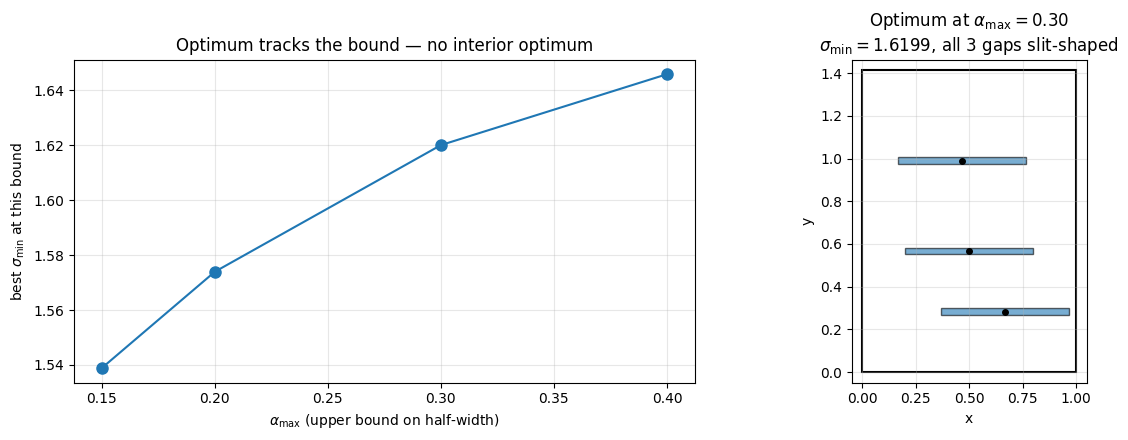

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: how the optimum changes as we widen the bound
ax = axes[0]
amaxs = [r[0] for r in results_sweep]
sigs  = [r[1] for r in results_sweep]
ax.plot(amaxs, sigs, "o-", markersize=8, color="tab:blue")
ax.set_xlabel(r"$\alpha_{\max}$ (upper bound on half-width)")
ax.set_ylabel(r"best $\sigma_{\min}$ at this bound")
ax.set_title("Optimum tracks the bound — no interior optimum")
ax.grid(alpha=0.3)

# Right: the optimal configuration at alpha_max = 0.30
ax = axes[1]
ax.add_patch(plt.Rectangle((0, 0), L, W, fill=False, edgecolor="black", linewidth=1.5))
for k in range(K_gaps):
    x0, y0 = z_v1[3*k], z_v1[3*k+1]
    al = z_v1[3*k+2]; be = a_0/(4*al)
    ax.add_patch(plt.Rectangle((x0-al, y0-be), 2*al, 2*be, alpha=0.6,
                               edgecolor="black", facecolor="tab:blue"))
    ax.plot(x0, y0, "ko", markersize=4)
ax.set_xlim(-0.05, L+0.05); ax.set_ylim(-0.05, W+0.05); ax.set_aspect("equal")
ax.set_title(f"Optimum at $\\alpha_{{\\max}}=0.30$\n$\\sigma_{{\\min}}={sigma_v1:.4f}$, all 3 gaps slit-shaped")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## What to take away

**Chain rule for area constraint, in one line.** When two design variables are tied by an equality constraint $g(\alpha, \beta) = 0$, parametrize one in terms of the other and add the chain-rule term to gradients. For $\beta = a_0/(4\alpha)$: $d/d\alpha\big|_\mathrm{constrained} = \partial/\partial\alpha - (\beta/\alpha)\partial/\partial\beta$. Verify with FD on the constrained variable.

**Bound-active does not mean done.** When your optimizer reports an optimum on a bound, the next step is to widen the bound and re-run — not to celebrate. Three outcomes:
- *Optimum moves slightly, stabilizes inside the new bound:* the original bound was wrong; the real optimum is interior.
- *Optimum stays at the new bound (and keeps improving):* there's no interior optimum in this parametric family. Either change the parametrization (might recover an optimum) or accept the formulation is degenerate (need a different objective or relaxation).
- *Optimum is right at the original bound and your problem says "this is a hard physical limit":* the bound is the answer; report it and explain why.

**Parametric degeneracy is a signal.** If your rectangular-family optimization runs to slits, that's evidence the underlying free-shape problem might be degenerate too. Worth checking with a free-shape (topology) formulation before committing to "the slit is best." Notebook 4 does that check.

**The next notebook** addresses the free-shape question directly. With density $\rho \in [0,1]^{n_\mathrm{el}}$ and SIMP topology optimization, what does the unrestricted optimum look like? The answer turns out to require diagnosing why a standard optimization tool fails when applied without checking its calibration assumptions.
